<a href="https://colab.research.google.com/github/beckhamtoh/CS3244-Gun-Violence/blob/main/Classifying_reasons_for_gun_incidents(baseline_models).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import pandas as pd

uploaded = files.upload()


Saving Guns incident Data.csv to Guns incident Data (2).csv


Inspecting the dataset

In [2]:
for filename in uploaded.keys():
    print(f"Loaded: {filename}")
    df = pd.read_csv(filename)

print(df.head())

Loaded: Guns incident Data (2).csv
   S.No.  Year  Month        Date   Reason     Education     Sex   Age  \
0      1  2017      1  06-01-2017  Suicide     Bachelors    Male  35.0   
1      2  2017      1  19-01-2017  Suicide  Some college  Female  22.0   
2      3  2017      1  01-01-2017  Suicide     Bachelors    Male  61.0   
3      4  2017      2  06-02-2017  Suicide     Bachelors    Male  65.0   
4      5  2017      2  09-02-2017  Suicide   High School    Male  32.0   

                     Race  Hispanic Place of incident  Police involvement  
0  Asian/Pacific Islander       100              Home                   0  
1                   White       100            Street                   0  
2                   White       100   Other specified                   0  
3                   White       100              Home                   0  
4                   White       100   Other specified                   0  


Splitting the data into x and y

In [3]:
y = df['Reason']
x = df.drop('Reason', axis = 1)
x = x.drop('S.No.', axis = 1)
x = x.drop('Date', axis = 1) # Not sure if I should drop date, year, month
x = x.drop('Year', axis = 1)
x = x.drop('Month', axis = 1)

print(x.head())

from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 20)

      Education     Sex   Age                    Race  Hispanic  \
0     Bachelors    Male  35.0  Asian/Pacific Islander       100   
1  Some college  Female  22.0                   White       100   
2     Bachelors    Male  61.0                   White       100   
3     Bachelors    Male  65.0                   White       100   
4   High School    Male  32.0                   White       100   

  Place of incident  Police involvement  
0              Home                   0  
1            Street                   0  
2   Other specified                   0  
3              Home                   0  
4   Other specified                   0  


Preprocessing for logistic regression


In [4]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

cat_cols = ["Education", "Sex", "Race", "Place of incident"]
num_cols = ["Age", "Hispanic", "Police involvement"]

# Replacing missing values with median and scaling numeric features
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Replacing missing values with class that appear the most frequent and one hot encoder (turns each class into its own 0 1 column)
cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Outputs a single unified matrix
preprocessor = ColumnTransformer([
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)
])

# comments: use one hot encoder instead of label encoder because for features with more than 2 categories label encoder will create some sort of ranking/ level difference when in fact there is not

Logistic Regression

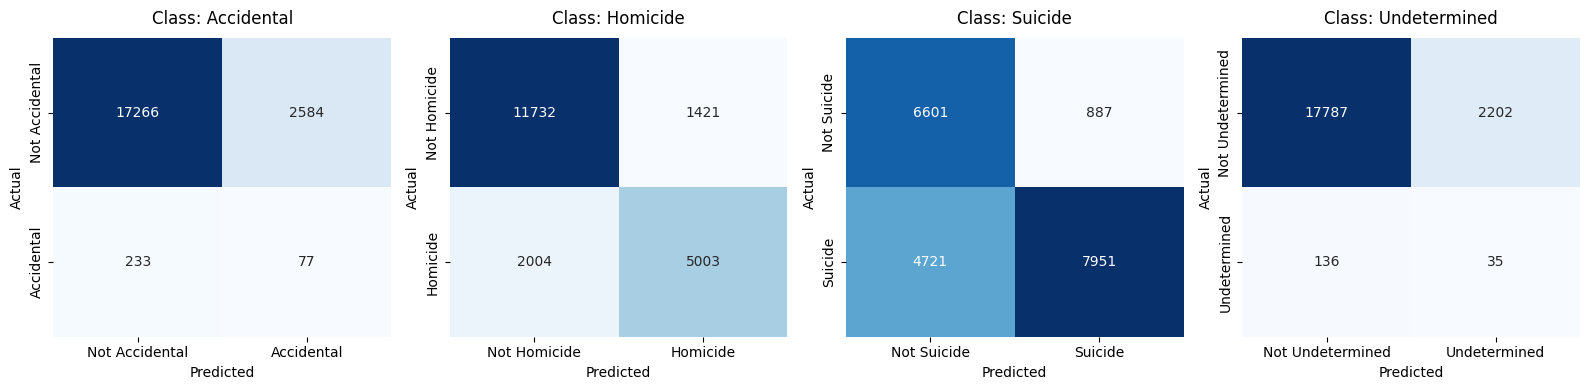

=== Logistic Regression Results ===
Accuracy: 0.6481
F1 (Macro): 0.3913

Classification Report:
              precision    recall  f1-score   support

  Accidental       0.03      0.25      0.05       310
    Homicide       0.78      0.71      0.74      7007
     Suicide       0.90      0.63      0.74     12672
Undetermined       0.02      0.20      0.03       171

    accuracy                           0.65     20160
   macro avg       0.43      0.45      0.39     20160
weighted avg       0.84      0.65      0.72     20160


=== Micro-Averaged Metrics ===
F1 Score: 0.6481
Precision: 0.6481
Recall: 0.6481


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, recall_score, precision_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.preprocessing import LabelEncoder

log_reg = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42, class_weight = "balanced"))
])

log_reg.fit(x_train, y_train)

# -------------------- Predict --------------------
y_pred = log_reg.predict(x_test)



# --- Get confusion matrix for each class ---
class_labels = log_reg.classes_
mcm = multilabel_confusion_matrix(y_test, y_pred, labels=class_labels)

# --- Plot one confusion matrix per class ---
fig, axes = plt.subplots(1, len(class_labels), figsize=(4 * len(class_labels), 4))

# Make sure axes is iterable even if there’s only one class
if len(class_labels) == 1:
    axes = [axes]

for ax, label, cm in zip(axes, class_labels, mcm):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)

    # Set readable class labels instead of numeric ticks
    ax.set_xticks([0.5, 1.5])
    ax.set_yticks([0.5, 1.5])
    ax.set_xticklabels([f'Not {label}', label])
    ax.set_yticklabels([f'Not {label}', label])

    ax.set_title(f'Class: {label}', fontsize=12, pad=10)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)


plt.tight_layout()
plt.show()

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

f1_micro = f1_score(y_test, y_pred, average="micro")
precision_micro = precision_score(y_test, y_pred, average="micro")
recall_micro = recall_score(y_test, y_pred, average="micro")

print("=== Logistic Regression Results ===")
print(f"Accuracy: {acc:.4f}")
print(f"F1 (Macro): {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("\n=== Micro-Averaged Metrics ===")
print(f"F1 Score: {f1_micro:.4f}")
print(f"Precision: {precision_micro:.4f}")
print(f"Recall: {recall_micro:.4f}")

# Comments:
# log_reg cannot capture non_linear relationship?
# class_weight = "balanced" gives higher importance to minority classes and lower weight to majority ones based on their frequency, helps to improve precision and recall scores for the minority classes
# If I use class_weight = None, I will get 0 for recall and precision for accidental and undetermined
# max_iter = 1000 becos we have 100,000+ entries and many features after one-hot encoding

# To improve:
# Can try different regularisations by tuning (eg penalty = "l1" and different C values in log_reg). Default is l2 regularization.
# Small C means strong penalty on large weights, coeff shrink leading to simpler model. Large c means negligible regularisation, model fits data more flexibly, risk of overfitting

KNN



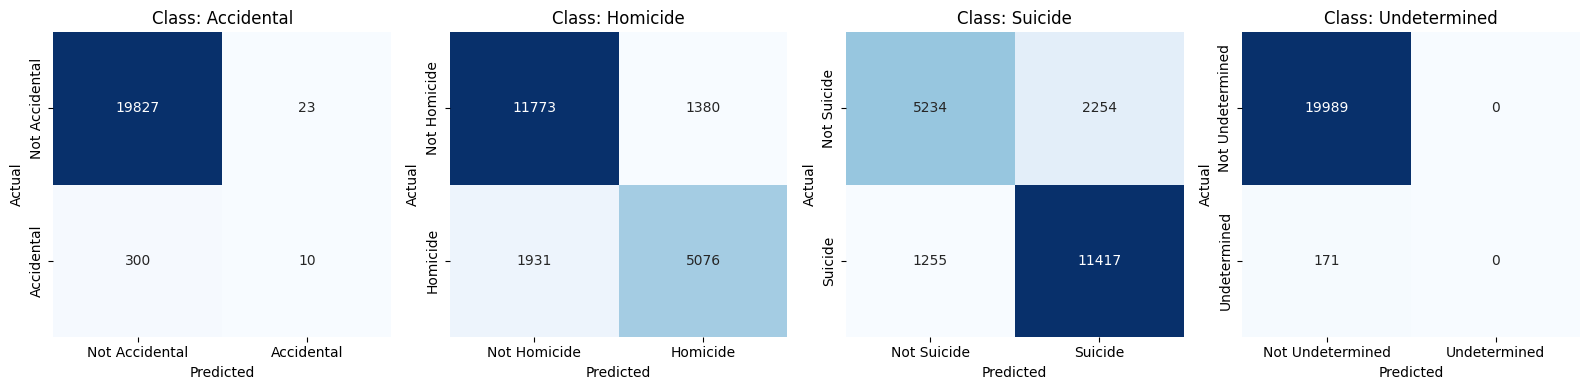

=== KNN (Manhattan) Results ===
Accuracy: 0.8186
F1 (Macro): 0.4198
Precision (Macro): 0.4811
Recall (Macro): 0.4144

Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.03      0.06       310
           1       0.79      0.72      0.75      7007
           2       0.84      0.90      0.87     12672
           3       0.00      0.00      0.00       171

    accuracy                           0.82     20160
   macro avg       0.48      0.41      0.42     20160
weighted avg       0.80      0.82      0.81     20160


=== Micro-Averaged Metrics ===
F1 Score: 0.8186
Precision: 0.8186
Recall: 0.8186


In [7]:
### PRE-PROCESSING ###
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder

# Encode the target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

x_train, x_test, y_train, y_test = train_test_split(x, y_encoded, test_size = 0.2, random_state = 20)


knn = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(
        n_neighbors=5,
        metric='manhattan',
        weights='uniform'
    ))
])

# --- Train the model ---
knn.fit(x_train, y_train)

# --- Predictions ---
y_pred = knn.predict(x_test)



# --- Get confusion matrix for each class ---
mcm = multilabel_confusion_matrix(y_test, y_pred, labels=knn.classes_)

# --- Plot one confusion matrix per class ---
fig, axes = plt.subplots(1, len(knn.classes_), figsize=(16, 4))

# Get the original class labels from the label encoder
original_labels = label_encoder.classes_

for i, (ax, label_index) in enumerate(zip(axes, knn.classes_)):
    cm = mcm[i]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Class: {original_labels[label_index]}') # Use original label for title
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.xaxis.set_ticklabels(['Not ' + original_labels[label_index], original_labels[label_index]]) # Use original labels for ticks
    ax.yaxis.set_ticklabels(['Not ' + original_labels[label_index], original_labels[label_index]]) # Use original labels for ticks


plt.tight_layout()
plt.show()

# --- Evaluation ---
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)

print("=== KNN (Manhattan) Results ===")
print(f"Accuracy: {acc:.4f}")
print(f"F1 (Macro): {f1:.4f}")
print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Recall (Macro): {recall_macro:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

f1_micro = f1_score(y_test, y_pred, average="micro")
precision_micro = precision_score(y_test, y_pred, average="micro")
recall_micro = recall_score(y_test, y_pred, average="micro")

print("\n=== Micro-Averaged Metrics ===")
print(f"F1 Score: {f1_micro:.4f}")
print(f"Precision: {precision_micro:.4f}")
print(f"Recall: {recall_micro:.4f}")

# Comments:
# I used random k = 5
# We have to use label encoder for KNN unlike in log_reg because KNN needs numeric y while models like log_reg, DT/Random Forest internally map class labels to numeric indices automatically using a built-in encoder.
# Use manhatten distance instead of euclidean distance because the dataset has categorical features and after one hot encoding, these features become binary (0/1).
# Manhattan measures how many binary positions differ — perfect for 0/1 data.
# Euclidean distance squares differences, which exaggerates large numeric gaps.
# Manhattan treats all dimensions more evenly → more robust with mixed scales.
# weights = "uniform" --> It’s simpler and more stable for noisy, real-world data. "uniform" avoids overfitting to the exact numeric scaling of features.
# weights = "distance" means closer neighbours gets more influence, distance weighted voting
# This takes quite long to run

# To improve:
# tune n_neighbours using k fold CV, maybe can try weights = "distance"?

Decision Tree

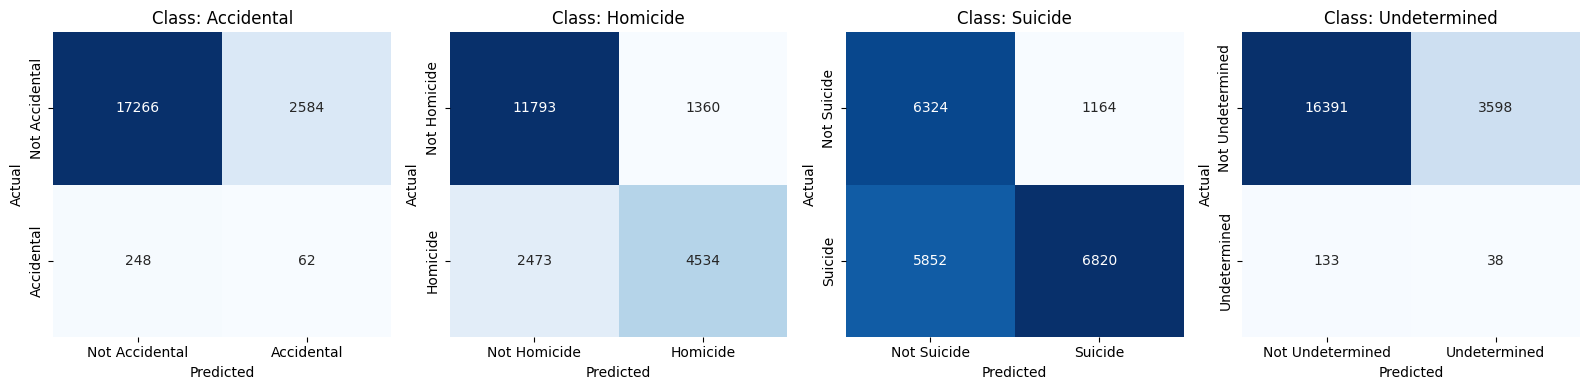

=== Decision Tree Results ===
Accuracy: 0.5682
F1 (Macro): 0.3563
Precision (Macro): 0.4143
Recall (Macro): 0.4019

Classification Report:
              precision    recall  f1-score   support

           0       0.02      0.20      0.04       310
           1       0.77      0.65      0.70      7007
           2       0.85      0.54      0.66     12672
           3       0.01      0.22      0.02       171

    accuracy                           0.57     20160
   macro avg       0.41      0.40      0.36     20160
weighted avg       0.80      0.57      0.66     20160


=== Micro-Averaged Metrics ===
F1 Score: 0.5682
Precision: 0.5682
Recall: 0.5682


In [14]:
from sklearn.tree import DecisionTreeClassifier

# --- Decision Tree Model ---
dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        criterion="entropy",     # or "gini"
        max_depth=None,          # you can limit depth to prevent overfitting
        class_weight="balanced", # handles imbalanced classes like 'Accidental' & 'Undetermined'
        random_state=42
    ))
])

# --- Train the model ---
dt_model.fit(x_train, y_train)

# --- Make predictions ---
y_pred = dt_model.predict(x_test)


# --- Get confusion matrix for each class ---
mcm = multilabel_confusion_matrix(y_test, y_pred, labels=dt_model.classes_)

# --- Plot one confusion matrix per class ---
fig, axes = plt.subplots(1, len(dt_model.classes_), figsize=(16, 4))

# Get the original class labels from the label encoder
original_labels = label_encoder.classes_

for i, (ax, label_index) in enumerate(zip(axes, dt_model.classes_)):
    cm = mcm[i]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Class: {original_labels[label_index]}') # Use original label for title
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.xaxis.set_ticklabels(['Not ' + original_labels[label_index], original_labels[label_index]]) # Use original labels for ticks
    ax.yaxis.set_ticklabels(['Not ' + original_labels[label_index], original_labels[label_index]]) # Use original labels for ticks


plt.tight_layout()
plt.show()

# --- Evaluate ---
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)

print("=== Decision Tree Results ===")
print(f"Accuracy: {acc:.4f}")
print(f"F1 (Macro): {f1:.4f}")
print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Recall (Macro): {recall_macro:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

f1_micro = f1_score(y_test, y_pred, average="micro")
precision_micro = precision_score(y_test, y_pred, average="micro")
recall_micro = recall_score(y_test, y_pred, average="micro")

print("\n=== Micro-Averaged Metrics ===")
print(f"F1 Score: {f1_micro:.4f}")
print(f"Precision: {precision_micro:.4f}")
print(f"Recall: {recall_micro:.4f}")

# Comment:
# I chose max_depth = None, no limit on depth
# If some classes have much more data than others, the model might “cheat” and just focus on predicting the majority class correctly to boost accuracy.
# We use class_weight = "balanced" beacause we have imbalanced data (Accidental and Undetermined have very little samples)
# class_weight = "balanced" -> Automatically gives rare classes more importance, Helps the model not ignore small classes like Accidental and Undetermined
# However, this does not seem to help much as the scores for accidental and undetermined are still quite low

# To improve:
# we could tweak max_depth, bagging boosting, RF, Decision Stumps
# Can find information gain of each feature to see which features are best at predicting/splitting. Maybe can remove those with low info gain?


Random Forest

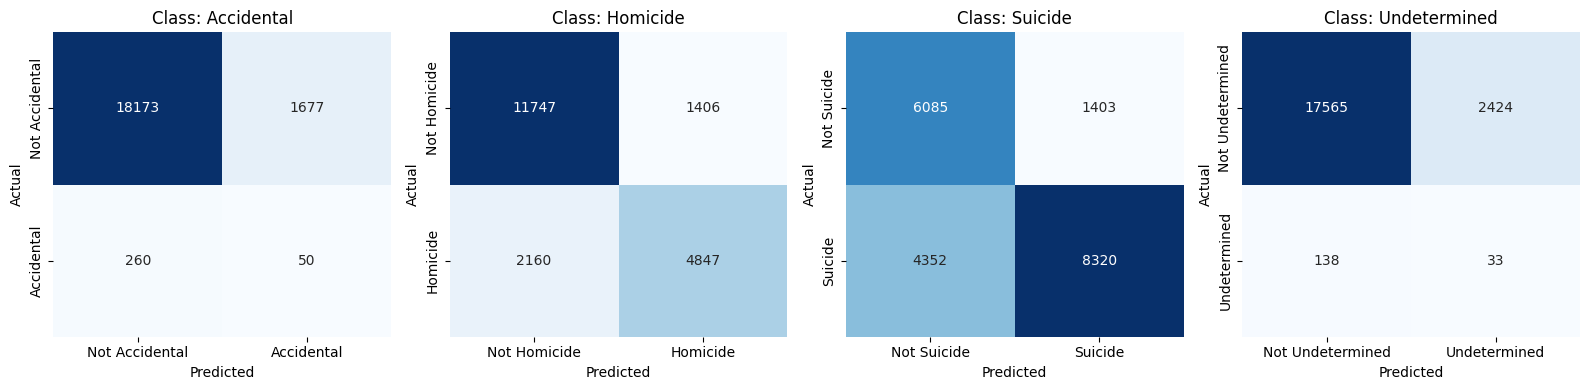

=== Random Forest Results ===
Accuracy: 0.6572
F1 (Macro): 0.3871
Precision (Macro): 0.4183
Recall (Macro): 0.4256

Classification Report:
              precision    recall  f1-score   support

           0       0.03      0.16      0.05       310
           1       0.78      0.69      0.73      7007
           2       0.86      0.66      0.74     12672
           3       0.01      0.19      0.03       171

    accuracy                           0.66     20160
   macro avg       0.42      0.43      0.39     20160
weighted avg       0.81      0.66      0.72     20160


=== Micro-Averaged Metrics ===
F1 Score: 0.6572
Precision: 0.6572
Recall: 0.6572


In [15]:
from sklearn.ensemble import RandomForestClassifier
# --- Random Forest Model ---
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,        # number of trees
        max_depth=None,          # allow trees to grow fully
        class_weight="balanced", # handle class imbalance
        random_state=42,
        n_jobs=-1                # use all CPU cores
    ))
])

# --- Train the model ---
rf_model.fit(x_train, y_train)

# --- Make predictions ---
y_pred = rf_model.predict(x_test)


### Confusion matrix ###

# --- Get confusion matrix for each class ---
mcm = multilabel_confusion_matrix(y_test, y_pred, labels=rf_model.classes_)

# --- Plot one confusion matrix per class ---
fig, axes = plt.subplots(1, len(rf_model.classes_), figsize=(16, 4))

# Get the original class labels from the label encoder
original_labels = label_encoder.classes_

for i, (ax, label_index) in enumerate(zip(axes, rf_model.classes_)):
    cm = mcm[i]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Class: {original_labels[label_index]}') # Use original label for title
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.xaxis.set_ticklabels(['Not ' + original_labels[label_index], original_labels[label_index]]) # Use original labels for ticks
    ax.yaxis.set_ticklabels(['Not ' + original_labels[label_index], original_labels[label_index]]) # Use original labels for ticks


plt.tight_layout()
plt.show()

# --- Evaluate ---
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)

print("=== Random Forest Results ===")
print(f"Accuracy: {acc:.4f}")
print(f"F1 (Macro): {f1:.4f}")
print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Recall (Macro): {recall_macro:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

f1_micro = f1_score(y_test, y_pred, average="micro")
precision_micro = precision_score(y_test, y_pred, average="micro")
recall_micro = recall_score(y_test, y_pred, average="micro")

print("\n=== Micro-Averaged Metrics ===")
print(f"F1 Score: {f1_micro:.4f}")
print(f"Precision: {precision_micro:.4f}")
print(f"Recall: {recall_micro:.4f}")

# Comments:
# Not sure if this is a baseline model, it could be an improvement to the baseline DT model
# Takes quite long to run also

# To improve:
# Can tune the no. of trees in the random forest and max_depth, can combine with bagging?

General Comments:




I dropped the date features, not sure if i should


Better to use micro metrics than macro metrics beacause of our imbalanced dataset. In general, the macro metrics is quite low for all models this is because of the low number of samples for accidental and undetermined classes

Accuracy and Micro metrics KNN is by far the best. But accuracy does not tell the full story

Can use other evaluation methods like AUC-ROC, PR-AUC  normalised confusion matrix to evaluate

Can check if model is underfitting or overfitting by comparing training performance vs test performance

To improve the models in general, we have to increase the samples of accidental and undetermined. We also have to tune certain parameters. We can also do feature engineering or feature selection. Find the top predictors?


